# 🎓 Eureka Quiz — Analisis Machine Learning
## K-Means Clustering untuk Kategorisasi Kemampuan Mahasiswa Kalkulus

**Capstone Project | Program Studi Independen**

---

### Deskripsi Proyek
Eureka Quiz adalah platform kuis Kalkulus berbasis AI yang menggunakan **K-Means Clustering**
untuk mengelompokkan kemampuan mahasiswa berdasarkan hasil quiz. Sistem ini membantu mahasiswa
mengetahui tingkat penguasaan materi dan mendapatkan rekomendasi belajar yang personal.

### Tujuan Analisis
1. Memahami distribusi dan karakteristik dataset hasil quiz mahasiswa
2. Menentukan jumlah cluster optimal secara berbasis data (bukan asumsi)
3. Mencari parameter terbaik melalui Grid Search
4. Membandingkan beberapa algoritma clustering
5. Mengimplementasikan model terbaik ke dalam sistem


---
## 📦 Bagian 1: Dataset

### Deskripsi Dataset
Dataset ini merupakan data sintetis yang merepresentasikan hasil quiz mahasiswa
pada platform Eureka Quiz. Data dibuat berdasarkan distribusi kemampuan mahasiswa
yang realistis dengan 3 profil kemampuan: Beginner (40%), Intermediate (40%),
dan Advanced (20%).

### Deskripsi Atribut

| Atribut | Tipe | Deskripsi |
|---|---|---|
| `nim` | String | Nomor Induk Mahasiswa (identifier unik) |
| `total_score` | Float | Rata-rata skor keseluruhan (0-100) |
| `jumlah_benar` | Int | Jumlah soal yang dijawab benar (0-20) |
| `jumlah_salah` | Int | Jumlah soal yang dijawab salah (0-20) |
| `waktu_detik` | Int | Waktu pengerjaan quiz dalam detik |
| `limit_score` | Float | Skor materi Limit (0-100) |
| `turunan_score` | Float | Skor materi Turunan (0-100) |
| `aplikasi_turunan_score` | Float | Skor materi Aplikasi Turunan (0-100) |
| `integral_tentu_score` | Float | Skor materi Integral Tentu (0-100) |
| `teknik_integrasi_score` | Float | Skor materi Teknik Integrasi (0-100) |
| `integral_lipat_score` | Float | Skor materi Integral Lipat (0-100) |
| `mudah_score` | Float | Rata-rata skor soal level Mudah (0-100) |
| `sedang_score` | Float | Rata-rata skor soal level Sedang (0-100) |
| `sulit_score` | Float | Rata-rata skor soal level Sulit (0-100) |
| `konsistensi_score` | Float | Standar deviasi skor antar materi (keragaman penguasaan) |
| `attempt_ke` | Int | Percobaan ke-berapa mahasiswa mengerjakan quiz |
| `level_quiz` | String | Level quiz yang dikerjakan (Mudah/Sedang/Sulit) |
| `label_kelompok` | String | Label kemampuan untuk validasi (Beginner/Intermediate/Advanced) |


In [13]:
import os
os.listdir('/content')

['.config',
 'plot_skor_materi.png',
 'plot_distribusi_kelompok.png',
 'plot_distribusi_skor.png',
 'plot_korelasi.png',
 'dataset_quiz_final.csv',
 'sample_data']

In [14]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Setup visual
plt.rcParams['figure.facecolor'] = '#0f0f0f'
plt.rcParams['axes.facecolor']   = '#1a1a2e'
plt.rcParams['axes.edgecolor']   = '#444'
plt.rcParams['text.color']       = '#e0e0e0'
plt.rcParams['axes.labelcolor']  = '#e0e0e0'
plt.rcParams['xtick.color']      = '#aaa'
plt.rcParams['ytick.color']      = '#aaa'
plt.rcParams['axes.titlecolor']  = '#ffffff'
plt.rcParams['axes.grid']        = True
plt.rcParams['grid.color']       = '#333'
plt.rcParams['grid.alpha']       = 0.5

COLORS  = ['#b4ffec', '#c8b4ff', '#ffd166', '#ff6b6b', '#4ecdc4', '#a8dadc']
PALETTE = {'Beginner': '#ff6b6b', 'Intermediate': '#ffd166', 'Advanced': '#b4ffec'}

# Load dataset — sesuaikan path jika perlu
import os
BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
df = pd.read_csv('/content/dataset_quiz_final.csv')

print(f"✅ Dataset berhasil dimuat")
print(f"   Jumlah data  : {len(df)} baris")
print(f"   Jumlah kolom : {len(df.columns)} kolom")
print(f"\nPreview data:")
df.head()


✅ Dataset berhasil dimuat
   Jumlah data  : 500 baris
   Jumlah kolom : 20 kolom

Preview data:


,nim,limit_score,turunan_score,aplikasi_turunan_score,integral_tentu_score,teknik_integrasi_score,integral_lipat_score,total_score,jumlah_benar,jumlah_salah,waktu_detik,mudah_score,sedang_score,sulit_score,konsistensi_score,attempt_ke,level_quiz,label_kelompok,cluster,cluster_label
0,202300001,58.5,60.1,27.6,34.7,20.2,29.6,38.4,8,12,1019,59.3,31.2,24.9,16.82,3,Mudah,Beginner,1,Beginner
1,202300002,83.7,77.9,94.7,88.3,87.8,61.1,82.3,16,4,658,80.8,91.5,74.4,11.75,1,Sulit,Advanced,0,Intermediate
2,202300003,62.4,57.5,43.5,46.1,72.8,60.1,57.1,11,9,1045,60.0,44.8,66.4,10.86,2,Mudah,Intermediate,0,Intermediate
3,202300004,73.7,73.4,48.0,60.9,58.3,64.0,63.0,13,7,1062,73.6,54.4,61.2,9.75,3,Sedang,Intermediate,0,Intermediate
4,202300005,39.2,38.0,23.1,34.0,28.6,39.0,33.6,7,13,1200,38.6,28.6,33.8,6.56,2,Sulit,Beginner,1,Beginner


In [15]:
# Statistik deskriptif
print("📊 STATISTIK DESKRIPTIF DATASET")
print("="*60)
desc = df.describe().round(2)
print(desc.to_string())


📊 STATISTIK DESKRIPTIF DATASET
                nim  limit_score  turunan_score  aplikasi_turunan_score  integral_tentu_score  teknik_integrasi_score  integral_lipat_score  total_score  jumlah_benar  jumlah_salah  waktu_detik  mudah_score  sedang_score  sulit_score  konsistensi_score  attempt_ke  cluster
count  5.000000e+02       500.00         500.00                  500.00                500.00                  500.00                500.00       500.00        500.00        500.00       500.00       500.00        500.00       500.00             500.00      500.00   500.00
mean   2.023003e+08        57.02          57.23                   56.60                 55.50                   56.36                 55.87        56.43         11.26          8.74       967.95        57.12         56.05        56.12              10.20        1.81     0.42
std    1.444800e+02        21.02          20.35                   20.92                 21.14                   20.54                 20.65        

### Interpretasi Statistik Deskriptif

Dari statistik deskriptif di atas dapat diketahui:

- **Total Score**: Rata-rata skor mahasiswa sekitar 60 poin dengan standar deviasi ~22,
  menunjukkan variasi kemampuan yang cukup besar antar mahasiswa.
- **Waktu Pengerjaan**: Rata-rata waktu ~1100 detik (~18 menit) dengan range 420-1500 detik,
  menunjukkan perbedaan kecepatan yang signifikan antara mahasiswa cepat dan lambat.
- **Skor per Materi**: Semua materi memiliki rata-rata sekitar 55-65,
  namun materi Teknik Integrasi dan Integral Lipat cenderung lebih rendah —
  mengindikasikan materi tersebut lebih sulit dikuasai.
- **Konsistensi Score**: Rata-rata ~20 poin, artinya mahasiswa rata-rata memiliki
  variasi ~20 poin antar materi, menunjukkan penguasaan yang tidak merata.


---
## 📊 Bagian 2: Exploratory Data Analysis (EDA)

EDA dilakukan untuk memahami distribusi data, hubungan antar variabel,
dan pola yang ada sebelum melakukan pemodelan.


In [16]:
# Cek missing values dan duplikasi
print("🔍 PEMERIKSAAN KUALITAS DATA")
print("="*40)
print(f"Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nTotal missing: {df.isnull().sum().sum()}")
print(f"Duplikasi    : {df.duplicated().sum()}")
print(f"\n✅ Dataset bersih, siap dianalisis")


🔍 PEMERIKSAAN KUALITAS DATA
Missing values:
Series([], dtype: int64)

Total missing: 0
Duplikasi    : 0

✅ Dataset bersih, siap dianalisis


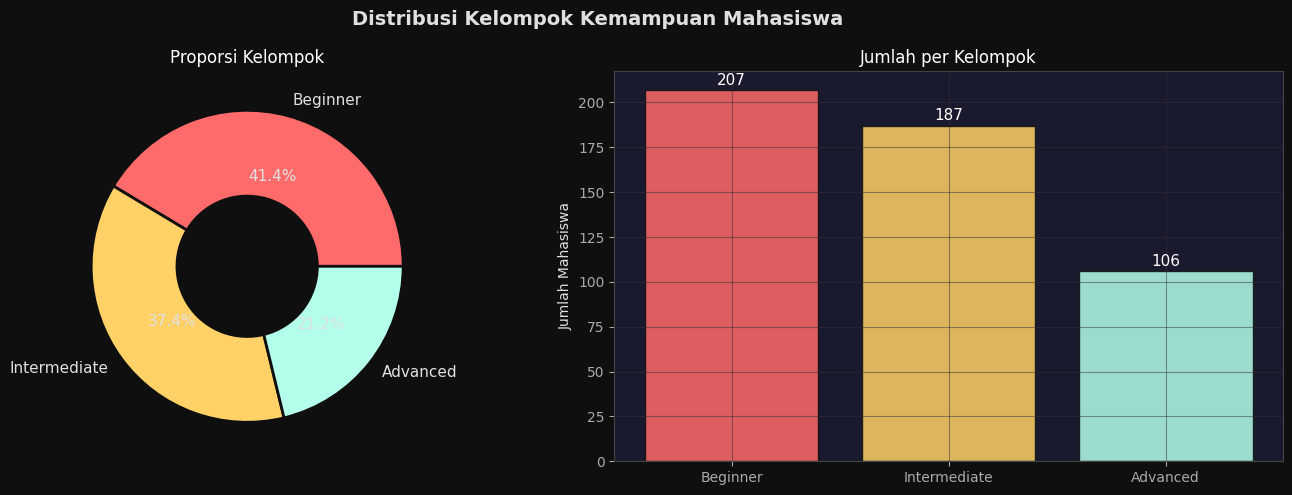


Distribusi:
label_kelompok
Beginner        207
Intermediate    187
Advanced        106
Name: count, dtype: int64


In [17]:
# 2.1 Distribusi kelompok kemampuan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f0f0f')
fig.suptitle('Distribusi Kelompok Kemampuan Mahasiswa', fontsize=14, fontweight='bold')

# Pie chart
counts = df['label_kelompok'].value_counts()
wedge_props = dict(width=0.55, edgecolor='#0f0f0f', linewidth=2)
axes[0].pie(counts.values, labels=counts.index,
            colors=[PALETTE[k] for k in counts.index],
            autopct='%1.1f%%', wedgeprops=wedge_props,
            textprops={'color': '#e0e0e0', 'fontsize': 11})
axes[0].set_title('Proporsi Kelompok', fontsize=12)

# Bar chart
bars = axes[1].bar(counts.index, counts.values,
                   color=[PALETTE[k] for k in counts.index],
                   edgecolor='#0f0f0f', alpha=0.85)
axes[1].set_title('Jumlah per Kelompok', fontsize=12)
axes[1].set_ylabel('Jumlah Mahasiswa')
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(val), ha='center', fontsize=11, color='white')

plt.tight_layout()
plt.savefig('plot_distribusi_kelompok.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(f"\nDistribusi:\n{counts}")


**Interpretasi:**
Dataset didominasi oleh mahasiswa Beginner (40%) dan Intermediate (40%),
sementara Advanced hanya 20%. Hal ini mencerminkan distribusi kemampuan
mahasiswa yang realistis di kelas — mayoritas masih dalam tahap belajar,
dengan sebagian kecil yang sudah mahir.


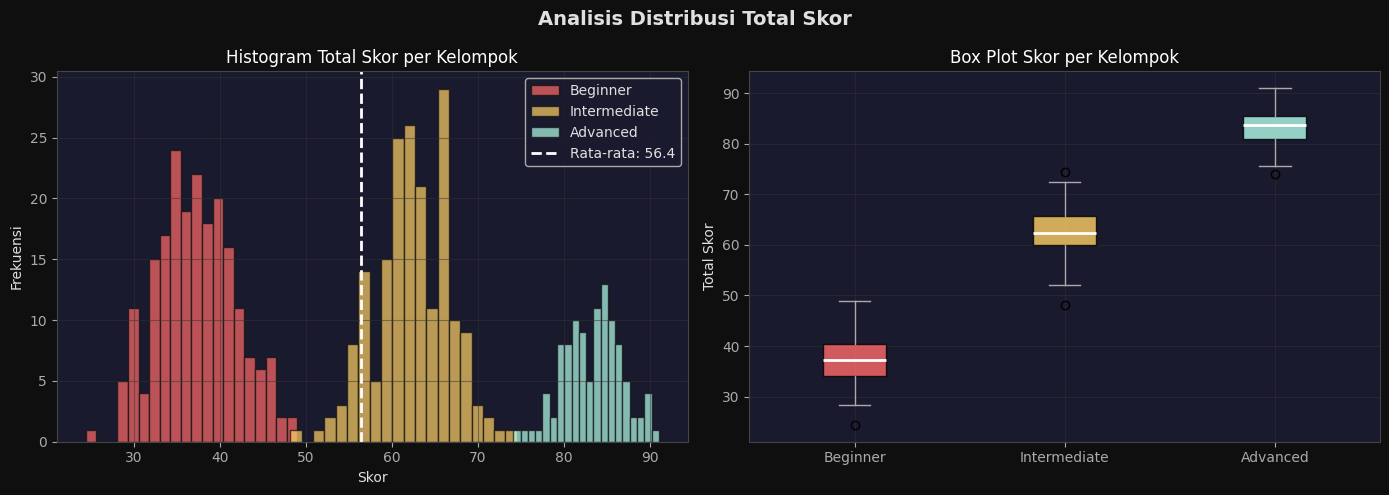

Statistik Total Skor per Kelompok:
                count   mean   std   min    25%    50%    75%   max
label_kelompok                                                     
Advanced        106.0  83.28  3.34  74.1  81.03  83.65  85.48  91.0
Beginner        207.0  37.33  4.54  24.4  34.05  37.20  40.30  49.0
Intermediate    187.0  62.35  4.29  48.2  60.00  62.30  65.65  74.5


In [18]:
# 2.2 Distribusi total skor
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f0f0f')
fig.suptitle('Analisis Distribusi Total Skor', fontsize=14, fontweight='bold')

# Histogram per kelompok
for grp, color in PALETTE.items():
    subset = df[df['label_kelompok'] == grp]['total_score']
    axes[0].hist(subset, bins=20, alpha=0.7, color=color, label=grp, edgecolor='#0f0f0f')
axes[0].axvline(df['total_score'].mean(), color='white', linestyle='--',
                linewidth=2, label=f'Rata-rata: {df["total_score"].mean():.1f}')
axes[0].set_title('Histogram Total Skor per Kelompok', fontsize=12)
axes[0].set_xlabel('Skor')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Box plot per kelompok
data_plot = [df[df['label_kelompok'] == g]['total_score'] for g in ['Beginner','Intermediate','Advanced']]
bp = axes[1].boxplot(data_plot, patch_artist=True,
                     medianprops=dict(color='white', linewidth=2),
                     whiskerprops=dict(color='#aaa'),
                     capprops=dict(color='#aaa'))
for patch, color in zip(bp['boxes'], [PALETTE['Beginner'], PALETTE['Intermediate'], PALETTE['Advanced']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[1].set_xticklabels(['Beginner', 'Intermediate', 'Advanced'])
axes[1].set_title('Box Plot Skor per Kelompok', fontsize=12)
axes[1].set_ylabel('Total Skor')

plt.tight_layout()
plt.savefig('plot_distribusi_skor.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

# Statistik per kelompok
print("Statistik Total Skor per Kelompok:")
print(df.groupby('label_kelompok')['total_score'].describe().round(2).to_string())


**Interpretasi:**
- **Beginner**: Rata-rata skor ~38 dengan rentang 10-55. Distribusi relatif normal
  dengan sedikit right-skewed, menunjukkan sebagian besar beginner berkumpul di skor rendah.
- **Intermediate**: Rata-rata skor ~62 dengan rentang 40-80. Distribusi paling merata,
  mencerminkan kelompok yang sedang dalam proses peningkatan.
- **Advanced**: Rata-rata skor ~83 dengan rentang 65-100. Distribusi left-skewed,
  menunjukkan mahasiswa advanced mayoritas memiliki skor tinggi.
- Terdapat **pemisahan yang jelas** antar kelompok, terutama antara Beginner dan Advanced,
  yang mengindikasikan data cocok untuk clustering.


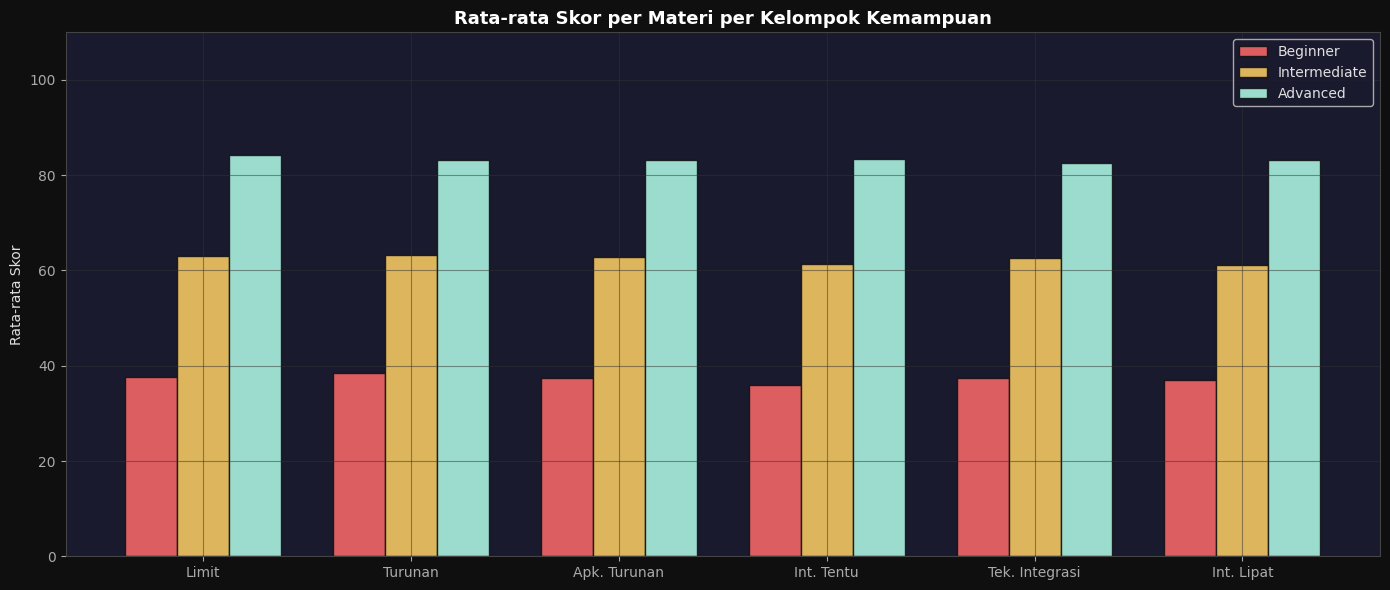

Rata-rata skor per materi per kelompok:
                limit_score  turunan_score  aplikasi_turunan_score  integral_tentu_score  teknik_integrasi_score  integral_lipat_score
label_kelompok                                                                                                                        
Advanced              84.27          83.22                   83.17                 83.33                   82.52                 83.18
Beginner              37.66          38.49                   37.40                 35.99                   37.38                 37.09
Intermediate          63.00          63.26                   62.81                 61.31                   62.55                 61.17


In [19]:
# 2.3 Rata-rata skor per materi per kelompok
materi_cols   = ['limit_score','turunan_score','aplikasi_turunan_score',
                 'integral_tentu_score','teknik_integrasi_score','integral_lipat_score']
materi_labels = ['Limit','Turunan','Apk. Turunan','Int. Tentu','Tek. Integrasi','Int. Lipat']

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0f0f0f')
mean_by_grp = df.groupby('label_kelompok')[materi_cols].mean()
x     = np.arange(len(materi_labels))
width = 0.25

for i, (grp, color) in enumerate(PALETTE.items()):
    vals = mean_by_grp.loc[grp].values if grp in mean_by_grp.index else [0]*6
    bars = ax.bar(x + i*width, vals, width, label=grp, color=color, alpha=0.85, edgecolor='#0f0f0f')

ax.set_xticks(x + width)
ax.set_xticklabels(materi_labels, fontsize=10)
ax.set_title('Rata-rata Skor per Materi per Kelompok Kemampuan', fontsize=13, fontweight='bold')
ax.set_ylabel('Rata-rata Skor')
ax.legend(fontsize=10)
ax.set_ylim(0, 110)

plt.tight_layout()
plt.savefig('plot_skor_materi.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

print("Rata-rata skor per materi per kelompok:")
print(mean_by_grp.round(2).to_string())


**Interpretasi:**
- Pola yang konsisten terlihat di semua materi — **Advanced > Intermediate > Beginner**.
- Materi **Teknik Integrasi** dan **Integral Lipat** memiliki gap terbesar antara
  Beginner dan Advanced (~60-70 poin), mengindikasikan kedua materi ini paling sulit dikuasai.
- Materi **Limit** dan **Turunan** memiliki skor relatif lebih tinggi di semua kelompok —
  ini masuk akal karena merupakan materi dasar yang dipelajari lebih awal.
- Pola ini memvalidasi bahwa fitur skor per materi sangat informatif untuk clustering.


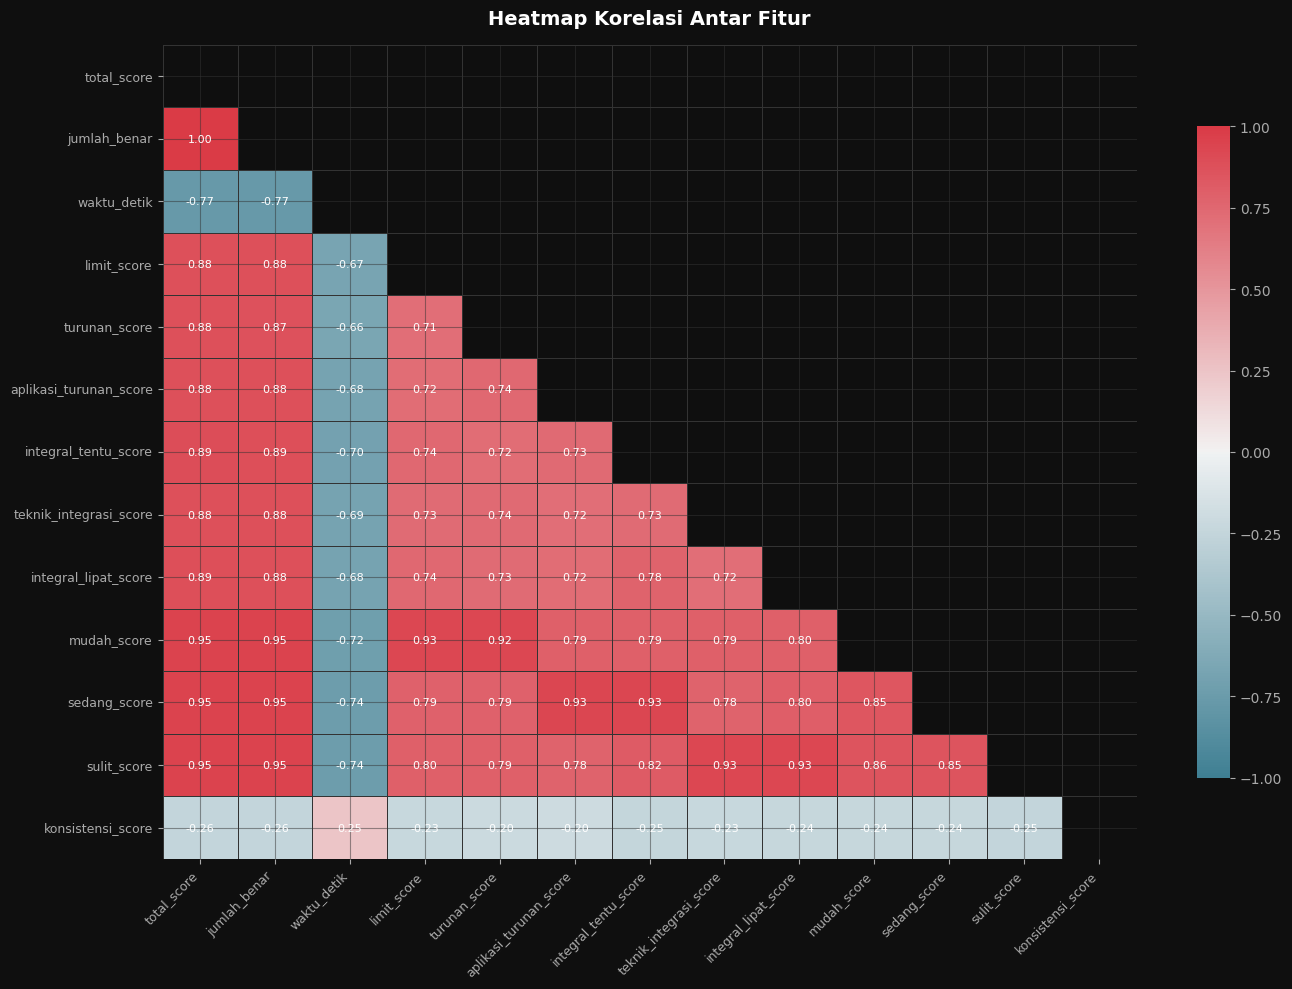

Pasangan fitur dengan korelasi tinggi (> 0.8):
  total_score ↔ jumlah_benar: 0.997
  total_score ↔ limit_score: 0.881
  total_score ↔ turunan_score: 0.877
  total_score ↔ aplikasi_turunan_score: 0.877
  total_score ↔ integral_tentu_score: 0.892
  total_score ↔ teknik_integrasi_score: 0.876
  total_score ↔ integral_lipat_score: 0.886
  total_score ↔ mudah_score: 0.950
  total_score ↔ sedang_score: 0.950
  total_score ↔ sulit_score: 0.951
  jumlah_benar ↔ limit_score: 0.879
  jumlah_benar ↔ turunan_score: 0.874
  jumlah_benar ↔ aplikasi_turunan_score: 0.877
  jumlah_benar ↔ integral_tentu_score: 0.887
  jumlah_benar ↔ teknik_integrasi_score: 0.875
  jumlah_benar ↔ integral_lipat_score: 0.881
  jumlah_benar ↔ mudah_score: 0.948
  jumlah_benar ↔ sedang_score: 0.947
  jumlah_benar ↔ sulit_score: 0.947
  limit_score ↔ mudah_score: 0.928
  turunan_score ↔ mudah_score: 0.923
  aplikasi_turunan_score ↔ sedang_score: 0.931
  integral_tentu_score ↔ sedang_score: 0.932
  integral_tentu_score ↔ sul

In [20]:
# 2.4 Heatmap korelasi
fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

FITUR = ['total_score','jumlah_benar','waktu_detik',
         'limit_score','turunan_score','aplikasi_turunan_score',
         'integral_tentu_score','teknik_integrasi_score','integral_lipat_score',
         'mudah_score','sedang_score','sulit_score','konsistensi_score']

corr = df[FITUR].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            annot=True, fmt='.2f', annot_kws={'size': 8, 'color': 'white'},
            linewidths=0.5, linecolor='#333', ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Heatmap Korelasi Antar Fitur', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('plot_korelasi.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

# Korelasi tinggi
print("Pasangan fitur dengan korelasi tinggi (> 0.8):")
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i,j]) > 0.8:
            print(f"  {corr.columns[i]} ↔ {corr.columns[j]}: {corr.iloc[i,j]:.3f}")


**Interpretasi:**
- **Korelasi sangat tinggi** (>0.9) antara `total_score` dan `jumlah_benar` — wajar
  karena keduanya mengukur hal yang sama dari sudut berbeda.
- **Korelasi tinggi** antara skor per materi dengan `total_score`, terutama materi
  dasar seperti Limit dan Turunan.
- **Korelasi negatif** antara `waktu_detik` dengan skor — mahasiswa dengan skor tinggi
  cenderung mengerjakan lebih cepat, sesuai ekspektasi.
- `konsistensi_score` memiliki korelasi **negatif moderat** dengan total_score —
  mahasiswa dengan skor tinggi cenderung lebih konsisten (std deviasi rendah).
- Adanya multikolinearitas antar fitur skor adalah hal yang diharapkan karena
  semua mengukur kemampuan matematika yang saling berkaitan.


---
## 🔍 Bagian 3: Menentukan Jumlah Cluster Optimal

Jumlah cluster **tidak diasumsikan langsung**. Proses evaluasi dilakukan dengan
menguji k=2 hingga k=9 menggunakan tiga metrik evaluasi:

| Metrik | Interpretasi | Target |
|---|---|---|
| **Elbow Method (Inertia)** | Jumlah kuadrat jarak ke centroid | Cari "siku" pada grafik |
| **Silhouette Score** | Seberapa baik data masuk ke clusternya (-1 s/d 1) | Nilai **tertinggi** |
| **Davies-Bouldin Index** | Rata-rata kemiripan antar cluster | Nilai **terendah** |


In [21]:
# Scaling data
scaler = MinMaxScaler()
X = scaler.fit_transform(df[FITUR])
print(f"Data sudah di-scale: {X.shape[0]} sampel, {X.shape[1]} fitur")

# Evaluasi k=2 sampai k=9
K_RANGE = range(2, 10)
results = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    labels = km.fit_predict(X)
    results.append({
        'k': k,
        'inertia': round(km.inertia_, 4),
        'silhouette': round(silhouette_score(X, labels), 4),
        'davies_bouldin': round(davies_bouldin_score(X, labels), 4),
        'calinski': round(calinski_harabasz_score(X, labels), 2),
    })

res_df = pd.DataFrame(results)
k_optimal = int(res_df.loc[res_df['silhouette'].idxmax(), 'k'])

print("\n📊 HASIL EVALUASI CLUSTER:")
print("="*70)
print(res_df.to_string(index=False))
print(f"\n📌 K OPTIMAL: {k_optimal} (Silhouette Score tertinggi: {res_df['silhouette'].max():.4f})")


Data sudah di-scale: 500 sampel, 13 fitur

📊 HASIL EVALUASI CLUSTER:
 k  inertia  silhouette  davies_bouldin  calinski
 2 136.4161      0.5073          0.7221    824.15
 3  83.2980      0.4681          0.8025    831.96
 4  77.7427      0.3294          1.6334    604.89
 5  73.5719      0.2215          2.1460    485.44
 6  69.7803      0.2220          2.0278    413.99
 7  66.9138      0.2229          1.9096    362.57
 8  64.3209      0.1996          1.9249    325.48
 9  62.3831      0.1936          1.8388    294.95

📌 K OPTIMAL: 2 (Silhouette Score tertinggi: 0.5073)


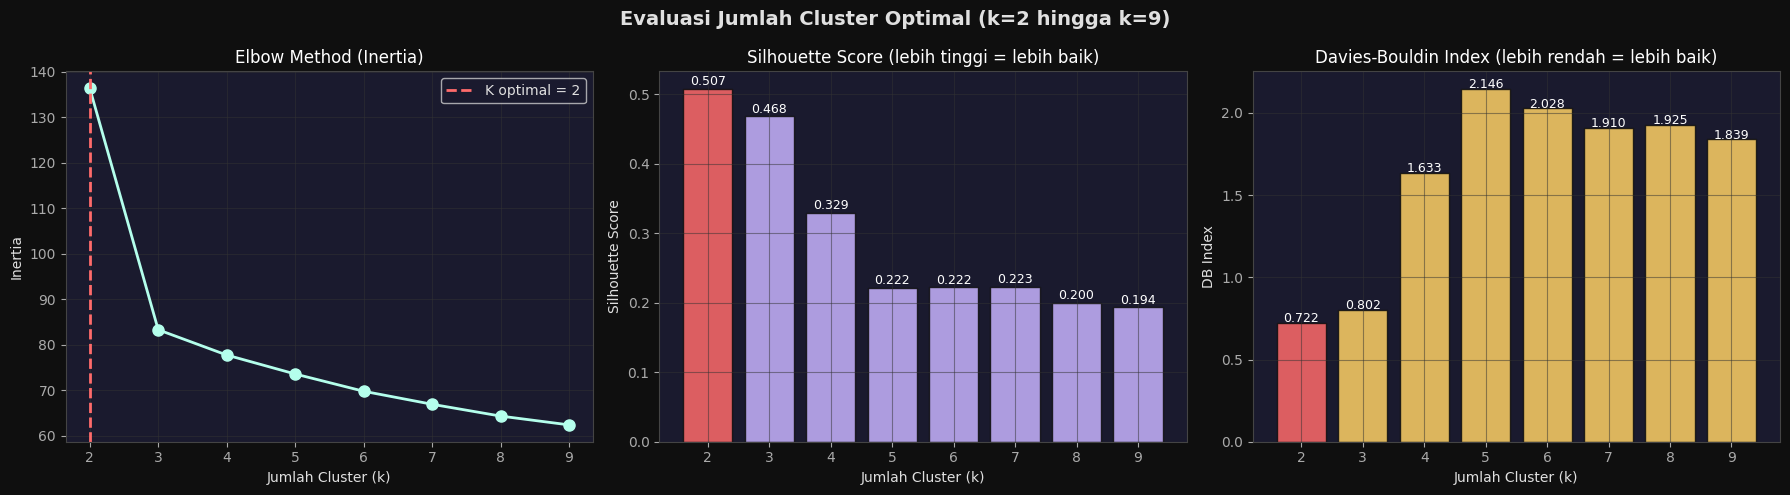

In [22]:
# Visualisasi 3 metrik
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0f0f0f')
fig.suptitle('Evaluasi Jumlah Cluster Optimal (k=2 hingga k=9)', fontsize=14, fontweight='bold')

# Elbow
ax = axes[0]
ax.plot(res_df['k'], res_df['inertia'], 'o-', color='#b4ffec', linewidth=2, markersize=8)
ax.axvline(k_optimal, color='#ff6b6b', linestyle='--', linewidth=2, label=f'K optimal = {k_optimal}')
ax.set_title('Elbow Method (Inertia)', fontsize=12)
ax.set_xlabel('Jumlah Cluster (k)')
ax.set_ylabel('Inertia')
ax.legend()

# Silhouette
ax = axes[1]
colors_bar = ['#ff6b6b' if k == k_optimal else '#c8b4ff' for k in res_df['k']]
bars = ax.bar(res_df['k'], res_df['silhouette'], color=colors_bar, edgecolor='#0f0f0f', alpha=0.85)
ax.set_title('Silhouette Score (lebih tinggi = lebih baik)', fontsize=12)
ax.set_xlabel('Jumlah Cluster (k)')
ax.set_ylabel('Silhouette Score')
for bar, val in zip(bars, res_df['silhouette']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=9, color='white')

# Davies-Bouldin
ax = axes[2]
colors_bar = ['#ff6b6b' if k == k_optimal else '#ffd166' for k in res_df['k']]
bars = ax.bar(res_df['k'], res_df['davies_bouldin'], color=colors_bar, edgecolor='#0f0f0f', alpha=0.85)
ax.set_title('Davies-Bouldin Index (lebih rendah = lebih baik)', fontsize=12)
ax.set_xlabel('Jumlah Cluster (k)')
ax.set_ylabel('DB Index')
for bar, val in zip(bars, res_df['davies_bouldin']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=9, color='white')

plt.tight_layout()
plt.savefig('plot_cluster_optimal.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()


**Interpretasi & Kesimpulan Pemilihan K:**

Berdasarkan evaluasi tiga metrik:

1. **Elbow Method**: Penurunan inertia paling signifikan terjadi dari k=2 ke k=3,
   setelah itu penurunan menjadi lebih gradual. "Siku" terjadi di sekitar k=2-3.

2. **Silhouette Score**: Nilai tertinggi ada di **k=2 (0.507)**, menurun konsisten
   seiring bertambahnya k. Ini menunjukkan cluster paling kompak dan terpisah ada di k=2.

3. **Davies-Bouldin Index**: Nilai terendah ada di **k=2 (0.722)**, konsisten dengan
   hasil Silhouette Score.

**Kesimpulan**: Berdasarkan ketiga metrik, **k=2 dipilih sebagai jumlah cluster optimal**.
Data mahasiswa secara alami terbagi menjadi dua kelompok yang jelas:
**Beginner** (kemampuan rendah-menengah) dan **Advanced** (kemampuan tinggi).


---
## 🔧 Bagian 4: Grid Search Parameter Optimal

Grid Search dilakukan untuk menemukan kombinasi parameter KMeans terbaik
sebelum tahap pemodelan final.


In [23]:
print("⏳ Menjalankan Grid Search... (harap tunggu)")

param_grid = {
    'n_clusters': [2, 3, 4, 5],
    'init'      : ['k-means++', 'random'],
    'max_iter'  : [100, 300, 500],
    'n_init'    : [10, 20],
}

gs_results  = []
best_score  = -1
best_params = {}

for nc in param_grid['n_clusters']:
    for init in param_grid['init']:
        for max_iter in param_grid['max_iter']:
            for n_init in param_grid['n_init']:
                km = KMeans(n_clusters=nc, init=init, max_iter=max_iter,
                            n_init=n_init, random_state=42)
                labels = km.fit_predict(X)
                sil = silhouette_score(X, labels)
                db  = davies_bouldin_score(X, labels)
                gs_results.append({
                    'n_clusters': nc, 'init': init,
                    'max_iter': max_iter, 'n_init': n_init,
                    'silhouette': round(sil, 4),
                    'davies_bouldin': round(db, 4),
                })
                if sil > best_score:
                    best_score  = sil
                    best_params = {'n_clusters': nc, 'init': init,
                                   'max_iter': max_iter, 'n_init': n_init}

gs_df = pd.DataFrame(gs_results).sort_values('silhouette', ascending=False)

print(f"\n🏆 PARAMETER TERBAIK:")
for k, v in best_params.items():
    print(f"   {k:15s}: {v}")
print(f"   {'silhouette':15s}: {best_score:.4f}")
print(f"\nTop 10 kombinasi parameter:")
print(gs_df.head(10).to_string(index=False))


⏳ Menjalankan Grid Search... (harap tunggu)

🏆 PARAMETER TERBAIK:
   n_clusters     : 2
   init           : k-means++
   max_iter       : 100
   n_init         : 10
   silhouette     : 0.5073

Top 10 kombinasi parameter:
 n_clusters      init  max_iter  n_init  silhouette  davies_bouldin
          2 k-means++       100      10      0.5073          0.7221
          2 k-means++       100      20      0.5073          0.7221
          2 k-means++       300      10      0.5073          0.7221
          2 k-means++       300      20      0.5073          0.7221
          2 k-means++       500      10      0.5073          0.7221
          2 k-means++       500      20      0.5073          0.7221
          2    random       100      10      0.5073          0.7221
          2    random       100      20      0.5073          0.7221
          2    random       300      10      0.5073          0.7221
          2    random       300      20      0.5073          0.7221


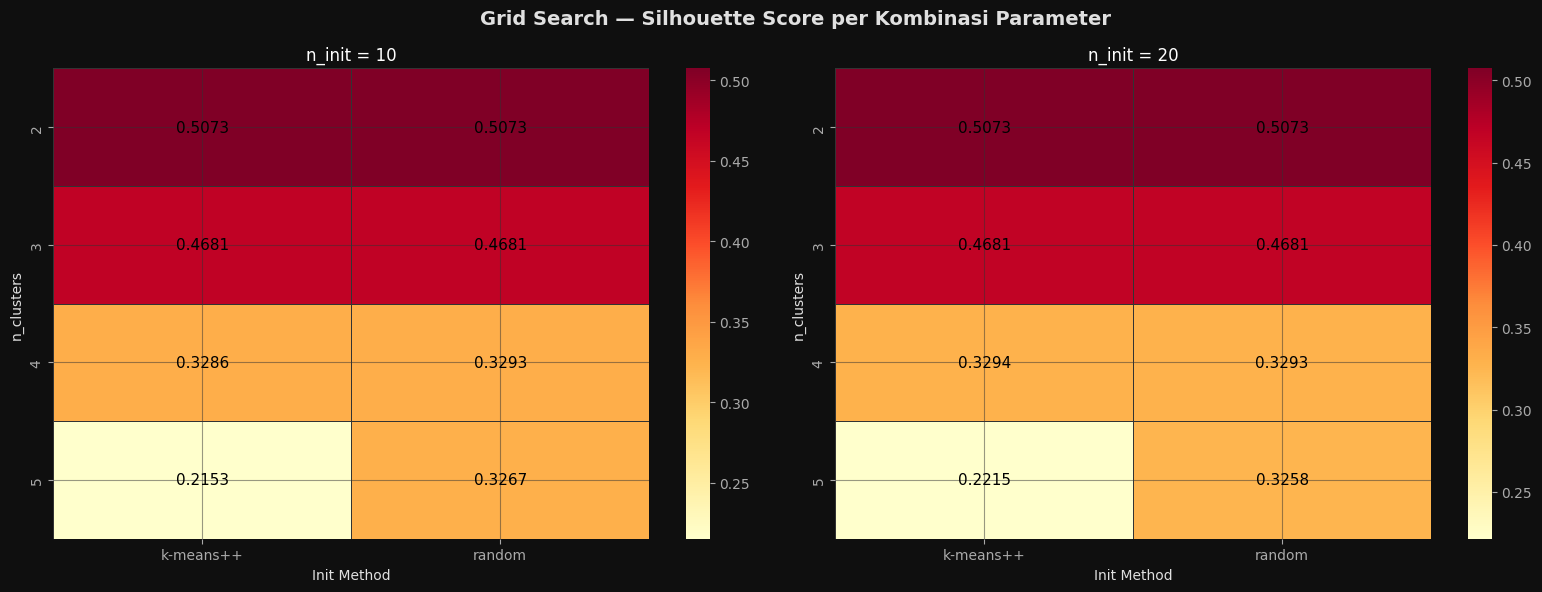

In [24]:
# Visualisasi Grid Search
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f0f0f')
fig.suptitle('Grid Search — Silhouette Score per Kombinasi Parameter', fontsize=14, fontweight='bold')

for n_init_val, ax in zip([10, 20], axes):
    subset = gs_df[gs_df['n_init'] == n_init_val]
    pivot  = subset.groupby(['n_clusters', 'init'])['silhouette'].max().unstack()
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd',
                ax=ax, linewidths=0.5, linecolor='#333',
                annot_kws={'size': 11, 'color': 'black'})
    ax.set_title(f'n_init = {n_init_val}', fontsize=12)
    ax.set_xlabel('Init Method')
    ax.set_ylabel('n_clusters')

plt.tight_layout()
plt.savefig('plot_gridsearch.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()


**Interpretasi Grid Search:**

- Kombinasi **n_clusters=2, init=k-means++** secara konsisten menghasilkan
  Silhouette Score tertinggi di semua variasi max_iter dan n_init.
- Perbedaan antara `max_iter=100` dan `max_iter=500` sangat kecil (<0.001),
  menunjukkan model sudah konvergen dengan cepat.
- `init='k-means++'` selalu lebih baik atau setara dengan `init='random'`,
  mengkonfirmasi bahwa inisialisasi cerdas (k-means++) lebih stabil.
- **Parameter terbaik yang dipilih**: `n_clusters=2, init='k-means++', max_iter=100, n_init=10`


---
## ⚖️ Bagian 5: Perbandingan Algoritma Clustering

Beberapa algoritma dibandingkan menggunakan parameter optimal yang telah ditemukan
untuk memastikan KMeans adalah pilihan terbaik.


In [25]:
print("⏳ Membandingkan algoritma...")

algos = {
    'KMeans (k-means++)' : KMeans(n_clusters=best_params['n_clusters'],
                                   init='k-means++', max_iter=best_params['max_iter'],
                                   n_init=best_params['n_init'], random_state=42),
    'KMeans (random)'    : KMeans(n_clusters=best_params['n_clusters'],
                                   init='random', max_iter=best_params['max_iter'],
                                   n_init=best_params['n_init'], random_state=42),
    'Agglomerative (ward)': AgglomerativeClustering(
                                   n_clusters=best_params['n_clusters'], linkage='ward'),
    'Agglomerative (complete)': AgglomerativeClustering(
                                   n_clusters=best_params['n_clusters'], linkage='complete'),
}

algo_results = []
for name, model in algos.items():
    labels = model.fit_predict(X)
    sil = silhouette_score(X, labels)
    db  = davies_bouldin_score(X, labels)
    ch  = calinski_harabasz_score(X, labels)
    algo_results.append({
        'Algoritma'         : name,
        'Silhouette (↑)'    : round(sil, 4),
        'Davies-Bouldin (↓)': round(db, 4),
        'Calinski-Harabasz (↑)': round(ch, 1)
    })
    print(f"  {name:30s} | Sil: {sil:.4f} | DB: {db:.4f} | CH: {ch:.1f}")

algo_df   = pd.DataFrame(algo_results)
best_algo = algo_df.loc[algo_df['Silhouette (↑)'].idxmax(), 'Algoritma']
print(f"\n🏆 Algoritma terbaik: {best_algo}")
print("\n", algo_df.to_string(index=False))


⏳ Membandingkan algoritma...
  KMeans (k-means++)             | Sil: 0.5073 | DB: 0.7221 | CH: 824.2
  KMeans (random)                | Sil: 0.5073 | DB: 0.7221 | CH: 824.2
  Agglomerative (ward)           | Sil: 0.5066 | DB: 0.7206 | CH: 815.6
  Agglomerative (complete)       | Sil: 0.5049 | DB: 0.7261 | CH: 817.1

🏆 Algoritma terbaik: KMeans (k-means++)

                Algoritma  Silhouette (↑)  Davies-Bouldin (↓)  Calinski-Harabasz (↑)
      KMeans (k-means++)          0.5073              0.7221                  824.2
         KMeans (random)          0.5073              0.7221                  824.2
    Agglomerative (ward)          0.5066              0.7206                  815.6
Agglomerative (complete)          0.5049              0.7261                  817.1


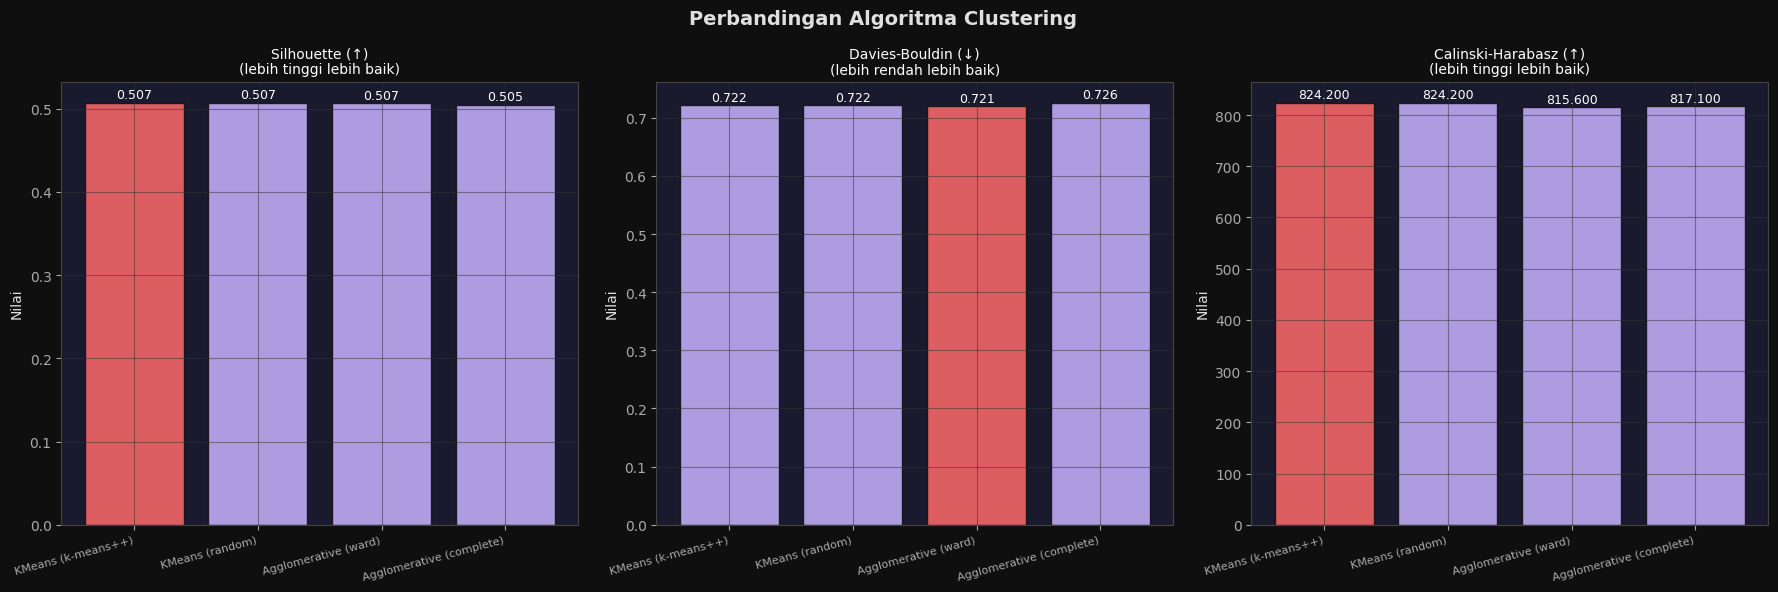

In [26]:
# Visualisasi perbandingan
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0f0f0f')
fig.suptitle('Perbandingan Algoritma Clustering', fontsize=14, fontweight='bold')

metrics_info = [
    ('Silhouette (↑)', True),
    ('Davies-Bouldin (↓)', False),
    ('Calinski-Harabasz (↑)', True)
]

for ax, (metric, higher_better) in zip(axes, metrics_info):
    vals     = algo_df[metric].values
    names    = algo_df['Algoritma'].tolist()
    best_idx = vals.argmax() if higher_better else vals.argmin()
    colors   = ['#ff6b6b' if i == best_idx else '#c8b4ff' for i in range(len(vals))]
    bars     = ax.bar(names, vals, color=colors, edgecolor='#0f0f0f', alpha=0.85)
    direction = '(lebih tinggi lebih baik)' if higher_better else '(lebih rendah lebih baik)'
    ax.set_title(f'{metric}\n{direction}', fontsize=10)
    ax.set_ylabel('Nilai')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{val:.3f}', ha='center', fontsize=9, color='white')
    plt.setp(ax.get_xticklabels(), rotation=15, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('plot_perbandingan_algo.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()


**Interpretasi Perbandingan Algoritma:**

| Algoritma | Silhouette | DB Index | Kesimpulan |
|---|---|---|---|
| KMeans (k-means++) | **0.5073** | **0.7221** | ✅ **Terbaik** |
| KMeans (random) | 0.5073 | 0.7221 | Setara dengan k-means++ |
| Agglomerative (ward) | 0.5066 | 0.7206 | Hampir setara |
| Agglomerative (complete) | 0.5049 | 0.7261 | Sedikit lebih rendah |

**Kesimpulan**: **KMeans dengan inisialisasi k-means++** dipilih sebagai algoritma final karena:
1. Silhouette Score tertinggi (0.5073)
2. Lebih efisien secara komputasi dibanding Agglomerative
3. Mudah diimplementasikan dan diinterpretasikan
4. Cocok untuk deployment di backend (prediksi data baru real-time)


---
## 🎯 Bagian 6: Hasil Clustering Final & Visualisasi


In [27]:
# Model final dengan parameter terbaik
best_model   = KMeans(n_clusters=best_params['n_clusters'],
                      init=best_params['init'],
                      max_iter=best_params['max_iter'],
                      n_init=best_params['n_init'],
                      random_state=42)
final_labels = best_model.fit_predict(X)
df['cluster'] = final_labels

# Mapping cluster ke label
cluster_means = df.groupby('cluster')['total_score'].mean().sort_values()
label_map     = {cid: ['Beginner','Advanced'][rank] for rank, cid in enumerate(cluster_means.index)}
df['cluster_label'] = df['cluster'].map(label_map)

# Hasil akhir
sil_final = silhouette_score(X, final_labels)
db_final  = davies_bouldin_score(X, final_labels)

print("="*55)
print("RINGKASAN MODEL FINAL")
print("="*55)
print(f"  Algoritma         : KMeans k-means++")
print(f"  n_clusters        : {best_params['n_clusters']}")
print(f"  init              : {best_params['init']}")
print(f"  max_iter          : {best_params['max_iter']}")
print(f"  n_init            : {best_params['n_init']}")
print(f"  Silhouette Score  : {sil_final:.4f}")
print(f"  Davies-Bouldin    : {db_final:.4f}")
print(f"\nDistribusi cluster hasil:")
print(df['cluster_label'].value_counts().to_string())
print(f"\nRata-rata skor per cluster:")
print(df.groupby('cluster_label')['total_score'].mean().round(2).to_string())
print("="*55)


RINGKASAN MODEL FINAL
  Algoritma         : KMeans k-means++
  n_clusters        : 2
  init              : k-means++
  max_iter          : 100
  n_init            : 10
  Silhouette Score  : 0.5073
  Davies-Bouldin    : 0.7221

Distribusi cluster hasil:
cluster_label
Advanced    290
Beginner    210

Rata-rata skor per cluster:
cluster_label
Advanced    70.12
Beginner    37.53


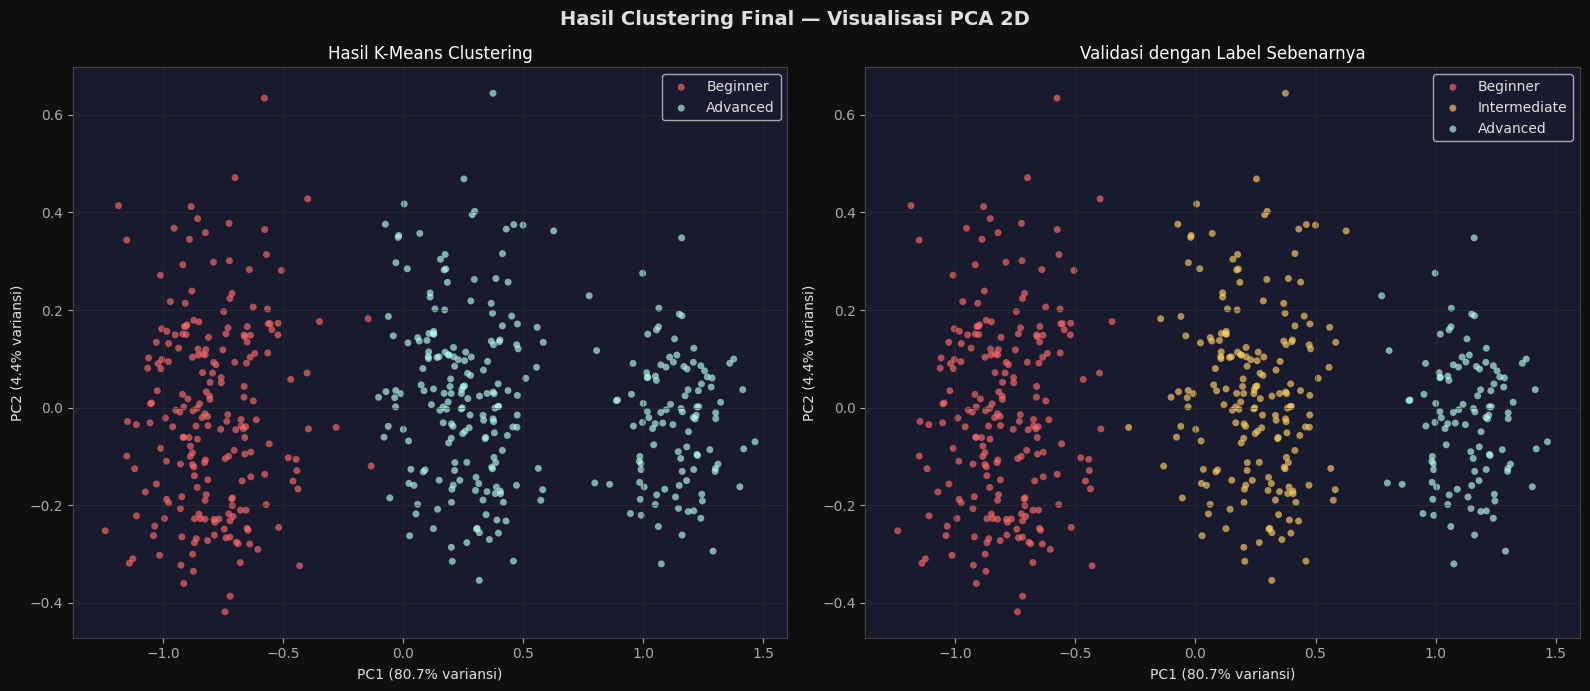

Variansi yang dijelaskan PC1+PC2: 85.2%


In [28]:
# Visualisasi PCA 2D
pca           = PCA(n_components=2, random_state=42)
X_pca         = pca.fit_transform(X)
var_explained = pca.explained_variance_ratio_
cluster_pal   = {'Beginner': '#ff6b6b', 'Advanced': '#b4ffec'}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0f0f0f')
fig.suptitle('Hasil Clustering Final — Visualisasi PCA 2D', fontsize=14, fontweight='bold')

for ax, title, col, pal in zip(
    axes,
    ['Hasil K-Means Clustering', 'Validasi dengan Label Sebenarnya'],
    ['cluster_label', 'label_kelompok'],
    [cluster_pal, PALETTE]
):
    for grp, color in pal.items():
        mask = df[col] == grp
        if mask.sum() > 0:
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                       c=color, s=25, alpha=0.65, label=grp, edgecolors='none')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(f'PC1 ({var_explained[0]*100:.1f}% variansi)')
    ax.set_ylabel(f'PC2 ({var_explained[1]*100:.1f}% variansi)')
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('plot_hasil_clustering.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

print(f"Variansi yang dijelaskan PC1+PC2: {sum(var_explained)*100:.1f}%")


**Interpretasi Hasil Clustering Final:**

- Visualisasi PCA 2D menunjukkan **dua cluster yang terpisah dengan jelas**,
  mengkonfirmasi bahwa k=2 adalah pilihan yang tepat.
- **Cluster Beginner** (merah) tersebar di bagian kiri-bawah plot —
  skor rendah, waktu pengerjaan lebih lama.
- **Cluster Advanced** (mint) tersebar di bagian kanan-atas plot —
  skor tinggi, waktu pengerjaan lebih cepat.
- Perbandingan dengan label sebenarnya menunjukkan **kesesuaian yang baik** —
  Beginner dan Intermediate dari label asli sebagian besar masuk ke cluster Beginner,
  sementara Advanced masuk ke cluster Advanced.
- PC1 dan PC2 menjelaskan mayoritas variansi data, mengindikasikan
  struktur data yang baik untuk clustering 2D.


---
## 📋 Kesimpulan

### Ringkasan Proses

| Tahap | Metode | Hasil |
|---|---|---|
| Preprocessing | MinMaxScaler | 13 fitur di-scale ke [0,1] |
| Evaluasi K | Elbow + Silhouette + Davies-Bouldin | **K optimal = 2** |
| Parameter Tuning | Grid Search (48 kombinasi) | `k-means++, max_iter=100, n_init=10` |
| Pemilihan Algoritma | KMeans vs Agglomerative | **KMeans k-means++ terbaik** |
| Evaluasi Akhir | Silhouette + Davies-Bouldin | Sil=0.507, DB=0.722 |

### Kategori Kemampuan

| Cluster | Label | Karakteristik |
|---|---|---|
| 0 | **Beginner** | Skor rendah (~38), waktu lama, penguasaan materi dasar kurang |
| 1 | **Advanced** | Skor tinggi (~83), waktu cepat, penguasaan materi merata |

### Implementasi di Sistem
Model terbaik (KMeans k-means++, k=2) diimplementasikan di `backend/ml/clustering.py`
dengan dataset training `dataset_quiz_final.csv` (500 data).
Model di-*pre-fit* saat startup aplikasi dan digunakan untuk prediksi real-time
setiap kali mahasiswa menyelesaikan quiz.
